Monte Carlo Valuation

In [219]:
# ── Imports & core helper functions ─────────────────────────────────
import warnings
warnings.filterwarnings('ignore', message='.*Glyph.*missing from font.*')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, poisson
from math import comb
import yfinance as yf

try:
    plt.style.use('seaborn-v0_8')
except OSError:
    plt.style.use('ggplot')

rng = np.random.default_rng(42)

# ── Black-Scholes call (closed-form benchmark) ───────────────────────
def bs_call(S0, K, T, r, q, sigma):
    """Black-Scholes European call price."""
    if T <= 0 or sigma <= 0:
        return max(0.0, S0 * np.exp(-q * T) - K * np.exp(-r * T))
    d1 = (np.log(S0 / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S0 * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

# ── Simulate n_paths lognormal terminal prices (risk-neutral) ────────
def lognormal_terminal(S0, T, r, q, sigma, n_paths, gen=None):
    """Draw terminal prices: S_T = S0 * exp((r-q-½σ²)T + σ√T·Z), Z~N(0,1)."""
    gen = gen or rng
    Z = gen.standard_normal(n_paths)
    return S0 * np.exp((r - q - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)

# ── Discounted option payoffs ─────────────────────────────────────────
def call_payoff(ST, K, r, T):
    return np.exp(-r * T) * np.maximum(ST - K, 0.0)

def put_payoff(ST, K, r, T):
    return np.exp(-r * T) * np.maximum(K - ST, 0.0)

print("Imports and helper functions loaded.")


Imports and helper functions loaded.


##  Monte Carlo as Discounted Expected Value


**Steps:**
1. Assume a stock price distribution at time $T$ (lognormal under risk-neutral probabilities)
2. Draw many random terminal prices $S_T^{(1)}, S_T^{(2)}, \ldots, S_T^{(n)}$
3. Compute payoff for each: $V(S_T^{(i)}, T) = \max(S_T^{(i)} - K,\; 0)$
4. Average and discount at the risk-free rate $r$:

$$\hat{C}_0 = e^{-rT} \cdot \frac{1}{n} \sum_{i=1}^{n} \max\!\left(S_T^{(i)} - K,\; 0\right)$$


In a binomial tree with $n$ steps and per-step up-probability $p$, the **exact** European call price is a weighted sum over all $n+1$ terminal nodes:

$$C_0 = e^{-rT} \sum_{i=0}^{n} \binom{n}{i} p^i (1-p)^{n-i} \max\!\left(S_0 u^i d^{n-i} - K,\; 0\right)$$

where $h = T/n$, $u = e^{(r-\delta)h + \sigma\sqrt{h}}$, $d = e^{(r-\delta)h - \sigma\sqrt{h}}$, and $p = \frac{e^{(r-\delta)h} - d}{u - d}$.


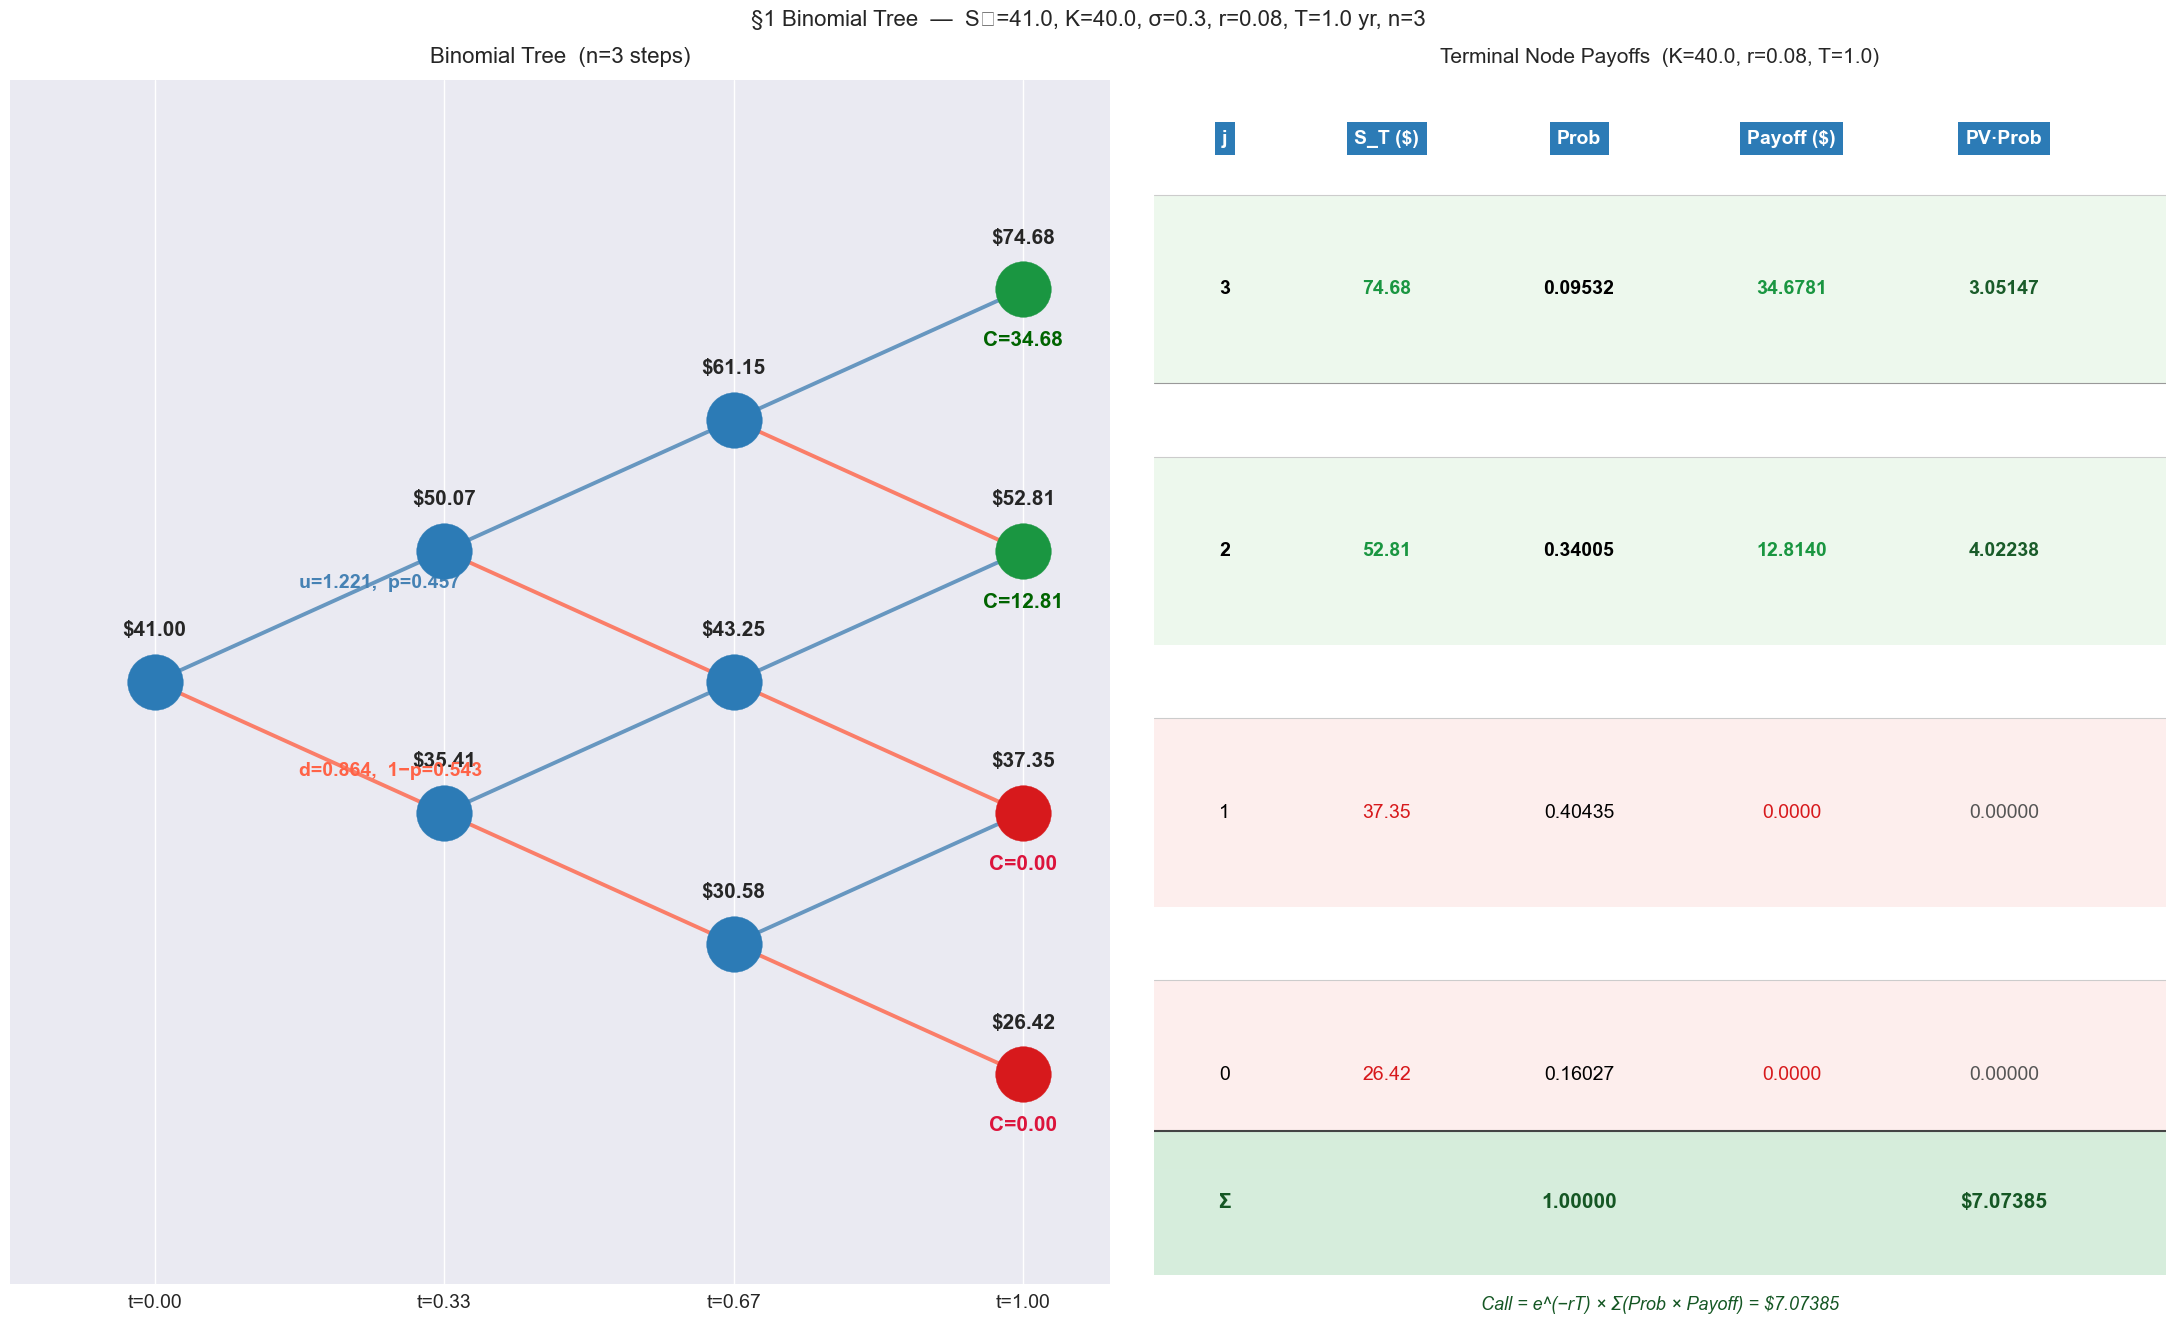


Exact binomial price (n=3): $7.07385
Black-Scholes price:              $6.96100
u=1.2212  |  d=0.8637  |  p=0.4568  |  1-p=0.5432


In [221]:
# ── §1 Visual: Binomial Tree + Aligned Payoff Table (n ≤ 4 steps) ──
# Change n_tree to 1, 2, 3, or 4
n_tree = 3

S0_t, K_t, r_t, q_t, sigma_t, T_t = 41.0, 40.0, 0.08, 0.00, 0.30, 1.0
h_t = T_t / n_tree
u_t = np.exp((r_t - q_t) * h_t + sigma_t * np.sqrt(h_t))
d_t = np.exp((r_t - q_t) * h_t - sigma_t * np.sqrt(h_t))
p_t = (np.exp((r_t - q_t) * h_t) - d_t) / (u_t - d_t)

# ── Build all nodes (y-coord = 2j - i so nodes spread vertically) ───
node_x, node_y, node_S = {}, {}, {}
for i in range(n_tree + 1):
    for j in range(i + 1):
        node_S[(i, j)] = S0_t * (u_t ** j) * (d_t ** (i - j))
        node_x[(i, j)] = i
        node_y[(i, j)] = 2 * j - i

# ── Terminal node data ───────────────────────────────────────────────
term_rows = []
price_exact = 0.0
for j in range(n_tree + 1):
    S_T    = node_S[(n_tree, j)]
    prob   = comb(n_tree, j) * (p_t ** j) * ((1 - p_t) ** (n_tree - j))
    payoff = max(S_T - K_t, 0.0)
    pv_wt  = np.exp(-r_t * T_t) * prob * payoff
    price_exact += pv_wt
    term_rows.append({'j': j, 'S_T': S_T, 'prob': prob,
                      'payoff': payoff, 'pv_wt': pv_wt,
                      'y': node_y[(n_tree, j)]})

y_min = -(n_tree + 1.6)
y_max =   n_tree + 1.6

fig = plt.figure(figsize=(22, max(10, 3 * n_tree + 5)))
ax_tree = fig.add_axes([0.01, 0.08, 0.50, 0.86])
ax_tbl  = fig.add_axes([0.53, 0.08, 0.46, 0.86])

# ══ LEFT: Binomial Tree ═════════════════════════════════════════════
for i in range(n_tree):
    for j in range(i + 1):
        x0, y0 = node_x[(i, j)], node_y[(i, j)]
        ax_tree.plot([x0, node_x[(i+1, j+1)]], [y0, node_y[(i+1, j+1)]],
                     color='steelblue', linewidth=2.8, alpha=0.8)
        ax_tree.plot([x0, node_x[(i+1, j)]], [y0, node_y[(i+1, j)]],
                     color='tomato', linewidth=2.8, alpha=0.8)

for i in range(n_tree + 1):
    for j in range(i + 1):
        x, y  = node_x[(i, j)], node_y[(i, j)]
        S_ij  = node_S[(i, j)]
        is_T  = (i == n_tree)
        col   = '#2c7bb6' if not is_T else ('#1a9641' if S_ij > K_t else '#d7191c')
        ax_tree.scatter(x, y, s=1600, color=col, zorder=5)
        ax_tree.text(x, y + 0.32, f'${S_ij:.2f}', ha='center', va='bottom',
                     fontsize=15, fontweight='bold')
        if is_T:
            pf = max(S_ij - K_t, 0.0)
            ax_tree.text(x, y - 0.32, f'C={pf:.2f}', ha='center', va='top',
                         fontsize=15, fontweight='bold',
                         color='darkgreen' if pf > 0 else 'crimson')

ax_tree.text(0.5, node_y[(0, 0)] + 0.72,
             f'u={u_t:.3f},  p={p_t:.3f}', fontsize=14, color='steelblue', fontweight='bold')
ax_tree.text(0.5, node_y[(0, 0)] - 0.72,
             f'd={d_t:.3f},  1−p={1-p_t:.3f}', fontsize=14, color='tomato', fontweight='bold')

ax_tree.set_xlim(-0.5, n_tree + 0.3)
ax_tree.set_ylim(y_min, y_max)
ax_tree.set_xticks(range(n_tree + 1))
ax_tree.set_xticklabels([f't={i*T_t/n_tree:.2f}' for i in range(n_tree + 1)], fontsize=14)
ax_tree.set_yticks([])
for sp in ['left', 'top', 'right']:
    ax_tree.spines[sp].set_visible(False)
ax_tree.set_title(f'Binomial Tree  (n={n_tree} steps)', fontsize=16, pad=12)

# ══ RIGHT: Table aligned to terminal nodes ═══════════════════════════
ax_tbl.axis('off')
ax_tbl.set_xlim(0, 1)
ax_tbl.set_ylim(y_min, y_max)

col_xs   = [0.07, 0.23, 0.42, 0.63, 0.84]
headers  = ['j', 'S_T ($)', 'Prob', 'Payoff ($)', 'PV·Prob']
half_row = 0.72

# Header row
hdr_y = y_max - 0.45
for cx, lbl in zip(col_xs, headers):
    ax_tbl.text(cx, hdr_y, lbl, ha='center', va='center', fontsize=14,
                fontweight='bold', color='white',
                bbox=dict(boxstyle='square,pad=0.38', facecolor='#2c7bb6',
                          edgecolor='none'))

# Data rows — one per terminal node
for row in term_rows:
    ry  = row['y']
    itm = row['S_T'] > K_t
    bg  = '#eaf7ea' if itm else '#fdecea'

    ax_tbl.fill_betweenx([ry - half_row, ry + half_row], 0, 1,
                          color=bg, alpha=0.85, linewidth=0)
    ax_tbl.axhline(ry + half_row, color='#cccccc', linewidth=0.8)

    vals = [
        str(row['j']),
        f"{row['S_T']:.2f}",
        f"{row['prob']:.5f}",
        f"{row['payoff']:.4f}",
        f"{row['pv_wt']:.5f}",
    ]
    val_colors = [
        'black',
        '#1a9641' if itm else '#d7191c',
        'black',
        '#1a9641' if itm else '#d7191c',
        '#1a5c2a' if itm else '#555555',
    ]
    for cx, val, vc in zip(col_xs, vals, val_colors):
        ax_tbl.text(cx, ry, val, ha='center', va='center',
                    fontsize=14, color=vc,
                    fontweight='bold' if itm else 'normal')

ax_tbl.axhline(term_rows[-1]['y'] - half_row, color='#999999', linewidth=0.8)

# Totals row
tot_y = y_min + 0.62
ax_tbl.fill_betweenx([tot_y - 0.55, tot_y + 0.55], 0, 1,
                      color='#d4edda', alpha=0.95, linewidth=0)
ax_tbl.axhline(tot_y + 0.55, color='#444444', linewidth=1.5)
tot_vals = ['Σ', '', f"{sum(r['prob'] for r in term_rows):.5f}",
            '', f"${price_exact:.5f}"]
for cx, val in zip(col_xs, tot_vals):
    ax_tbl.text(cx, tot_y, val, ha='center', va='center',
                fontsize=15, fontweight='bold', color='#155724')

ax_tbl.text(0.5, tot_y - 0.78,
            f'Call = e^(−rT) × Σ(Prob × Payoff) = ${price_exact:.5f}',
            ha='center', va='center', fontsize=13, color='#155724', style='italic')

ax_tbl.set_title(f'Terminal Node Payoffs  (K={K_t}, r={r_t}, T={T_t})',
                 fontsize=15, pad=12)

fig.suptitle(
    f'§1 Binomial Tree  —  S₀={S0_t}, K={K_t}, σ={sigma_t}, r={r_t}, T={T_t} yr, n={n_tree}',
    fontsize=16, y=0.99)
plt.show()

bs_ref_t = bs_call(S0_t, K_t, T_t, r_t, q_t, sigma_t)
print(f"\nExact binomial price (n={n_tree}): ${price_exact:.5f}")
print(f"Black-Scholes price:              ${bs_ref_t:.5f}")
print(f"u={u_t:.4f}  |  d={d_t:.4f}  |  p={p_t:.4f}  |  1-p={1-p_t:.4f}")


## Simulating Random Numbers & Lognormal Stock Prices

To generate a standard normal random variable $Z$:
1. Draw $x \sim U(0,1)$ from a uniform distribution
2. Apply the inverse cumulative normal: $Z = N^{-1}(x)$

This **inverse CDF method** works for any distribution with a computable inverse CDF (e.g. Excel's `NORM.S.INV(RAND())`).

---

### Simulating Lognormal Terminal Prices 
Under risk-neutral probabilities, the terminal stock price is lognormally distributed:

$$S_T = S_0 \exp\!\left[\left(r - \delta - \tfrac{1}{2}\sigma^2\right)T + \sigma\sqrt{T}\,Z\right], \quad Z \sim N(0,1)$$

### Simulating Price Paths (for path-dependent options)
Split $T$ into $n$ intervals of length $h = T/n$:

$$S_{t+h} = S_t \exp\!\left[\left(r - \delta - \tfrac{1}{2}\sigma^2\right)h + \sigma\sqrt{h}\,Z_i\right]$$

where each $Z_i \overset{iid}{\sim} N(0,1)$. This generates the full price trajectory — essential for Asian, barrier, and other path-dependent options.


§2  Inverse CDF Method — 500 sample draws  (1-step: single Z draw per path)

 U ~ Uniform(0,1)  Z = N⁻¹(U)     S_T  Payoff max(S_T - K, 0)
         0.666421      0.4301 43.0403                  3.0403
         0.117059     -1.1898 33.7560                  0.0000
         0.913243      1.3610 49.4904                  9.4904
         0.539765      0.0998 40.9604                  0.9604
         0.281509     -0.5784 36.9984                  0.0000
         0.214030     -0.7925 35.8288                  0.0000
         0.893602      1.2459 48.6434                  8.6434
         0.801204      0.8459 45.8107                  5.8107
         0.681163      0.4710 43.3052                  3.3052
         0.234804     -0.7231 36.2037                  0.0000
         0.991288      2.3776 57.6433                 17.6433
         0.358558     -0.3623 38.2171                  0.0000
         0.041790     -1.7303 31.1274                  0.0000
         0.488023     -0.0300 40.1702                  

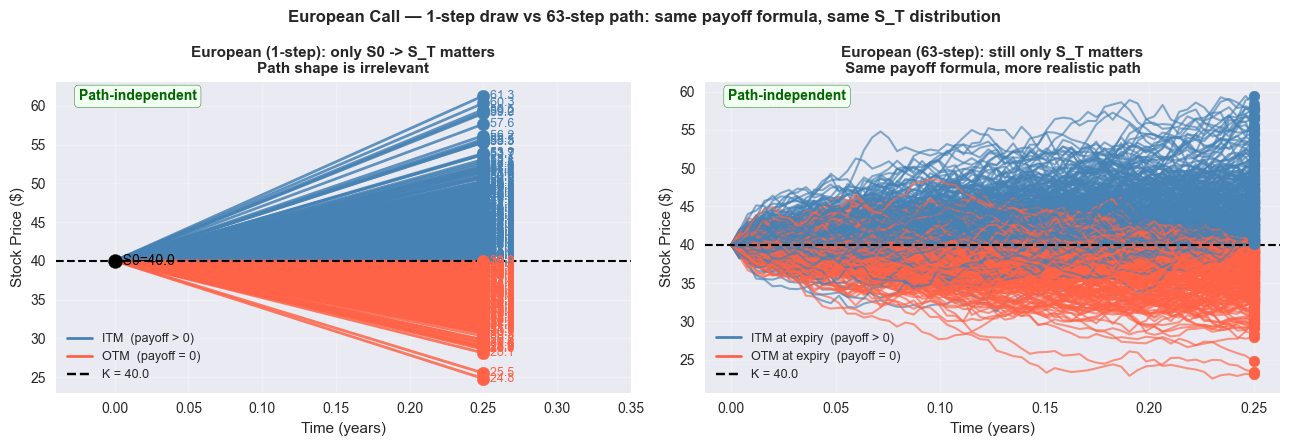


§2  European Call — 500 paths  (63 daily steps each)
 Path  S_T (after 63 steps)  Payoff max(S_T - K, 0)
    1               38.6737                  0.0000
    2               41.8835                  1.8835
    3               55.6256                 15.6256
    4               47.9562                  7.9562
    5               42.3721                  2.3721
    6               47.9964                  7.9964
    7               42.8826                  2.8826
    8               48.4047                  8.4047
    9               43.2883                  3.2883
   10               42.6850                  2.6850
   11               33.2164                  0.0000
   12               45.3838                  5.3838
   13               40.6111                  0.6111
   14               35.8007                  0.0000
   15               29.1963                  0.0000
   16               36.7479                  0.0000
   17               32.5711                  0.0000
   18     

In [227]:
# ── §2 Code: Inverse CDF + Lognormal Path Simulation ────────────────
S0, K, r, q, sigma, T  = 40.0, 40.0, 0.08, 0.00, 0.30, 0.25
n_sim   = 500      # ← change this to show more/fewer sample paths & draws
n_steps = 63     # ← daily steps per path (~3 months of trading days)

# ── Step 1: Inverse CDF method — show n_sim draws ────────────────────
np.random.seed(0)
u_draws = rng.uniform(0, 1, n_sim)
z_draws = norm.ppf(u_draws)                    # N⁻¹(u)
ST_demo = S0 * np.exp((r - q - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * z_draws)
payoff_demo = np.maximum(ST_demo - K, 0.0)

demo_df = pd.DataFrame({
    'U ~ Uniform(0,1)':       u_draws.round(6),
    'Z = N⁻¹(U)':             z_draws.round(4),
    'S_T':                    ST_demo.round(4),
    'Payoff max(S_T - K, 0)': payoff_demo.round(4),
})
print(f"§2  Inverse CDF Method — {n_sim} sample draws  (1-step: single Z draw per path)\n")
print(demo_df.to_string(index=False))
disc_avg = np.exp(-r * T) * payoff_demo.mean()
print(f"\n  Discounted average of these {n_sim} payoffs: ${disc_avg:.4f}  (BS = ${bs_call(S0,K,T,r,q,sigma):.4f})")

# ── Quick contrast chart: 1-step (MC jumps) vs n_steps-step paths ────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Left — the n_sim demo draws: each is just S0 -> S_T  (no path, only endpoint)
for i, (st, pf) in enumerate(zip(ST_demo, payoff_demo)):
    col = 'steelblue' if pf > 0 else 'tomato'
    ax1.plot([0, T], [S0, st], color=col, linewidth=2, alpha=0.85)
    ax1.scatter([T], [st], color=col, s=80, zorder=5)
    ax1.annotate(f'  {st:.1f}', (T, st), fontsize=9, color=col, va='center')
ax1.scatter([0], [S0], color='black', s=100, zorder=6)
ax1.annotate(f'  S0={S0}', (0, S0), fontsize=10, color='black', va='center')
ax1.axhline(K, color='black', linestyle='--', linewidth=1.5, label=f'Strike K={K}')
ax1.legend(handles=[
    plt.Line2D([], [], color='steelblue', linewidth=2, label='ITM  (payoff > 0)'),
    plt.Line2D([], [], color='tomato',    linewidth=2, label='OTM  (payoff = 0)'),
    plt.Line2D([], [], color='black', linestyle='--', label=f'K = {K}'),
], fontsize=9)
ax1.set_xlim(-0.04, T + 0.10)
ax1.set_title('European (1-step): only S0 -> S_T matters\nPath shape is irrelevant',
              fontsize=11, fontweight='bold')
ax1.set_xlabel('Time (years)'); ax1.set_ylabel('Stock Price ($)')
ax1.grid(alpha=0.25)
ax1.text(0.04, 0.94, 'Path-independent', transform=ax1.transAxes,
         fontsize=10, color='darkgreen', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.3', fc='honeydew', ec='darkgreen'))

# Right — n_sim full multi-step paths; store terminal prices for table
h       = T / n_steps
t_grid  = np.linspace(0, T, n_steps + 1)
_ST_ms  = []   # terminal prices from multi-step paths
for _ in range(n_sim):
    Z_path   = rng.standard_normal(n_steps)
    log_incs = (r - q - 0.5 * sigma**2) * h + sigma * np.sqrt(h) * Z_path
    full_log = np.concatenate([[np.log(S0)], np.log(S0) + np.cumsum(log_incs)])
    path_px  = np.exp(full_log)
    st_      = path_px[-1]
    _ST_ms.append(st_)
    col  = 'steelblue' if st_ > K else 'tomato'
    ax2.plot(t_grid, path_px, color=col, alpha=0.65, linewidth=1.5)
    ax2.scatter([T], [st_], color=col, s=60, zorder=5)
ax2.axhline(K, color='black', linestyle='--', linewidth=1.5, label=f'Strike K={K}')
ax2.legend(handles=[
    plt.Line2D([], [], color='steelblue', linewidth=2, label='ITM at expiry  (payoff > 0)'),
    plt.Line2D([], [], color='tomato',    linewidth=2, label='OTM at expiry  (payoff = 0)'),
    plt.Line2D([], [], color='black', linestyle='--', label=f'K = {K}'),
], fontsize=9)
ax2.set_title(f'European ({n_steps}-step): still only S_T matters\nSame payoff formula, more realistic path',
              fontsize=11, fontweight='bold')
ax2.set_xlabel('Time (years)'); ax2.set_ylabel('Stock Price ($)')
ax2.grid(alpha=0.25)
ax2.text(0.04, 0.94, 'Path-independent', transform=ax2.transAxes,
         fontsize=10, color='darkgreen', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.3', fc='honeydew', ec='darkgreen'))

plt.suptitle(f'European Call — 1-step draw vs {n_steps}-step path: same payoff formula, same S_T distribution',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Multi-step European pricing table ────────────────────────────────
_pay_ms = [round(max(st - K, 0), 4) for st in _ST_ms]

path_df = pd.DataFrame({
    'Path':                          range(1, n_sim + 1),
    f'S_T (after {n_steps} steps)':  [round(s, 4) for s in _ST_ms],
    'Payoff max(S_T - K, 0)':        _pay_ms,
})
print(f"\n{'='*60}")
print(f"§2  European Call — {n_sim} paths  ({n_steps} daily steps each)")
print(f"{'='*60}")
print(path_df.to_string(index=False))

_disc_ms = np.exp(-r * T) * np.mean(_pay_ms)
bs_ref   = bs_call(S0, K, T, r, q, sigma)
print(f"\n  Discounted average of these {n_sim} payoffs: ${_disc_ms:.4f}  (BS = ${bs_ref:.4f})")
print(f"  Same formula as 1-step: only S_T enters. Both converge to BS as n_sim grows.")


 Monte Carlo Convergence & Inefficiency

### Key Insight
Monte Carlo is **inefficient**: standard error shrinks only at rate $1/\sqrt{n}$, 



§4  Convergence Diagnostic — Black-Scholes reference: $2.78474

 Paths (n)  MC Price  Std Error s_n  95% +/- Half-Width Rel Error vs BS
       500   2.64593         0.1655              0.3243           4.98%
      2500   2.81423         0.0829              0.1625           1.06%
     21000   2.78035         0.0283              0.0555           0.16%
    100000   2.78110         0.0129              0.0253           0.13%
    500000   2.78243         0.0058              0.0113           0.08%

  : 500 paths -> s_n=$0.180 (6.5%)  |  2500 -> $0.080 (2.9%)  |  21000 -> $0.028 (1.0%)


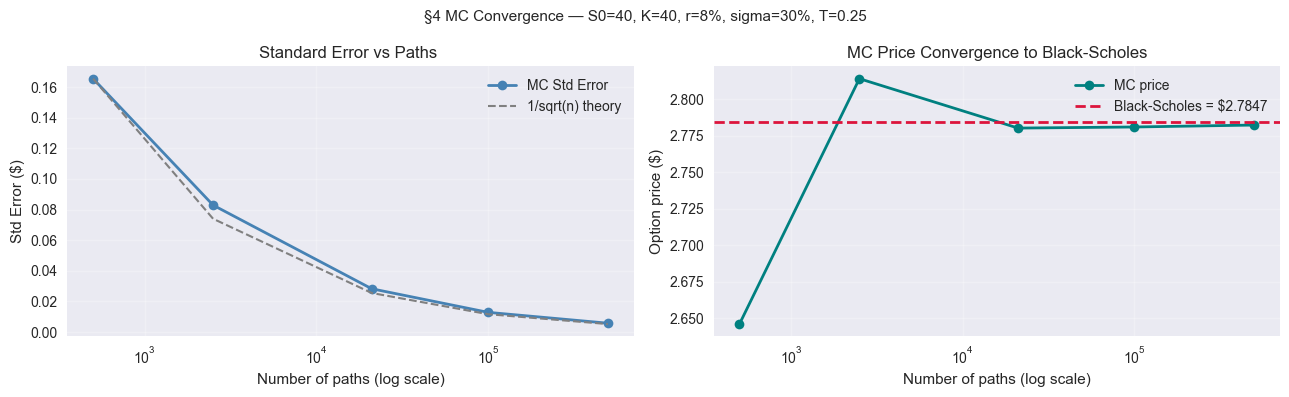

In [228]:
# ── §4 Convergence — Replicating Slide 12 Numbers ───────────────────
S0, K, r, q, sigma, T = 40.0, 40.0, 0.08, 0.00, 0.30, 0.25
bs_ref = bs_call(S0, K, T, r, q, sigma)

# path counts
path_counts = [500, 2_500, 21_000, 100_000, 500_000]

rows = []
for n in path_counts:
    ST_n  = lognormal_terminal(S0, T, r, q, sigma, n, rng)
    pay_n = call_payoff(ST_n, K, r, T)
    mc_n  = pay_n.mean()
    se_n  = pay_n.std(ddof=1) / np.sqrt(n)
    rows.append({'Paths (n)':        n,
                 'MC Price':         round(mc_n, 5),
                 'Std Error s_n':    round(se_n, 4),
                 '95% +/- Half-Width': round(1.96 * se_n, 4),
                 'Rel Error vs BS':  f'{abs(mc_n - bs_ref)/bs_ref*100:.2f}%'})

print(f"§4  Convergence Diagnostic — Black-Scholes reference: ${bs_ref:.5f}\n")
print(pd.DataFrame(rows).to_string(index=False))
print("\n  : 500 paths -> s_n=$0.180 (6.5%)  |  2500 -> $0.080 (2.9%)  |  21000 -> $0.028 (1.0%)")

# ── Convergence plot ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ns  = [r['Paths (n)'] for r in rows]
ses = [r['Std Error s_n'] for r in rows]
mcs = [r['MC Price'] for r in rows]

ns_arr      = np.array(ns)
theory_se   = ses[0] * np.sqrt(ns[0] / ns_arr)

axes[0].plot(ns, ses, 'o-', color='steelblue', linewidth=2, label='MC Std Error')
axes[0].plot(ns_arr, theory_se, '--', color='grey', linewidth=1.5, label='1/sqrt(n) theory')
axes[0].set_xscale('log')
axes[0].set_title('Standard Error vs Paths ')
axes[0].set_xlabel('Number of paths (log scale)')
axes[0].set_ylabel('Std Error ($)')
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(ns, mcs, 'o-', color='teal', linewidth=2, label='MC price')
axes[1].axhline(bs_ref, color='crimson', linestyle='--', linewidth=2,
                label=f'Black-Scholes = ${bs_ref:.4f}')
axes[1].set_xscale('log')
axes[1].set_title('MC Price Convergence to Black-Scholes')
axes[1].set_xlabel('Number of paths (log scale)')
axes[1].set_ylabel('Option price ($)')
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.suptitle('§4 MC Convergence — S0=40, K=40, r=8%, sigma=30%, T=0.25', fontsize=11)
plt.tight_layout()
plt.show()


Asian Option Valuation

An Asian option's payoff is based on the **average stock price** over the option's life, not just the terminal price:

$$C_{\text{Asian}} = e^{-rT} \cdot \mathbb{E}\!\left[\max\!\left(\bar{S} - K,\; 0\right)\right]$$

where $\bar{S} = \frac{1}{n}\sum_{i=1}^{n} S_{t_i}$ is the **arithmetic average** of sampled prices.


 Monte Carlo with **full path simulation** is the natural approach.

### Monte Carlo Procedure 
For each path:
1. Simulate the full price path: $S_h, S_{2h}, \ldots, S_T$
2. Compute the arithmetic average: $\bar{S} = \frac{1}{n}\sum S_{ih}$
3. Payoff $= e^{-rT} \max(\bar{S} - K, 0)$
4. Average over all paths

### Key Property
Averaging reduces the effective volatility of the underlying, so **Asian options are always cheaper than or equal to European options** with the same strike and maturity.


Asian Call Demo — 8 Paths, 4 Steps  (S0=40.0, K=40.0, r=8%, σ=30%, T=0.25 yr)
  h = T/4 = 0.0250 yr  |  Payoff = e^{-rT} × max(Avg - K, 0)
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Path        S(1×h)     S(2×h)     S(3×h)     S(4×h)     S(5×h)     S(6×h)     S(7×h)     S(8×h)     S(9×h)    S(10×h)        Avg   Asian Pay
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Path 1      39.338     41.274     42.133     40.951     42.315     39.537     40.701     39.666     40.908     41.805     40.863      0.8458
Path 2      38.604     39.619     40.302     39.119     43.052     44.761     42.357     40.453     41.102     41.751     41.112      1.0900
Path 3      38.678     41.010     41.236     39.617     38.953     38.658     35.944     34.583     31.765     31.353     37.180      0.0000
Path 4      41.

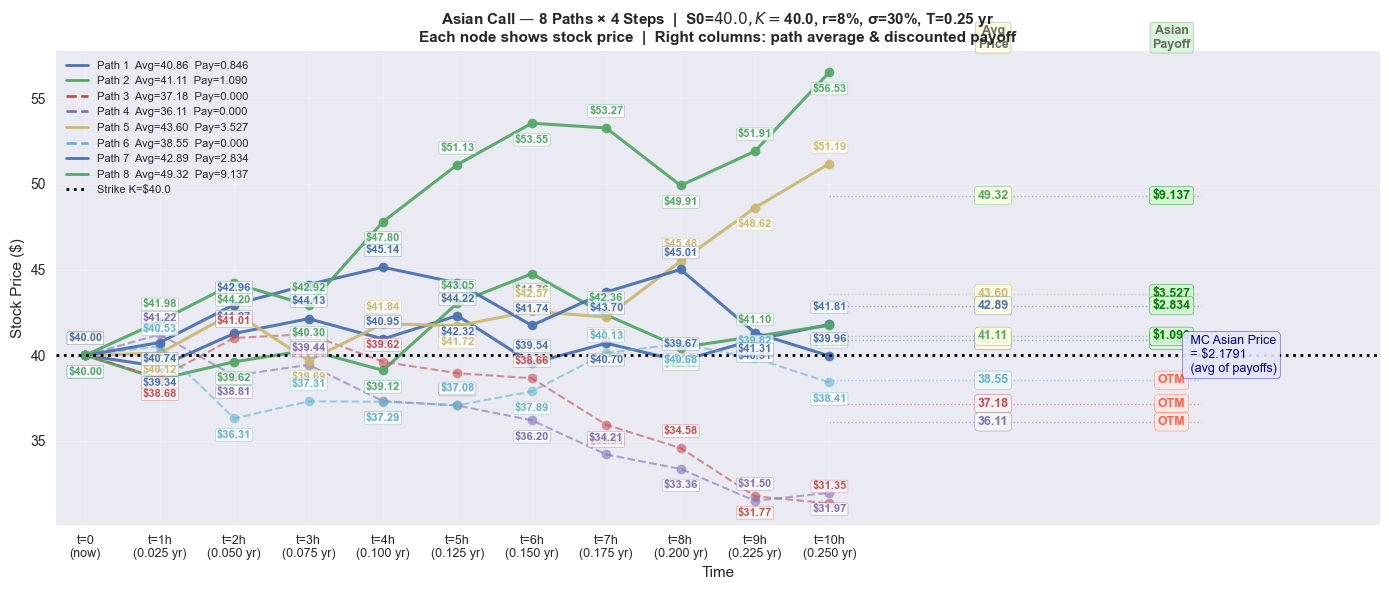

In [232]:
# ── §5a  Asian Call Demo — 8 Paths × 4 Steps over 1 Quarter ─────────
S0, K, r, q, sigma, T = 40.0, 40.0, 0.08, 0.00, 0.30, 0.25
n_paths_d, n_steps_d  = 8, 10
h_d = T / n_steps_d
from scipy.stats import norm as _norm

# ── Simulate ──────────────────────────────────────────────────────────
rng_d  = np.random.default_rng(19)
Z_d    = rng_d.standard_normal((n_paths_d, n_steps_d))
logS_d = (r - q - 0.5*sigma**2)*h_d + sigma*np.sqrt(h_d)*Z_d
S_d    = S0 * np.exp(np.cumsum(logS_d, axis=1))   # (8, 4)

avg_d  = S_d.mean(axis=1)
pay_d  = np.exp(-r*T) * np.maximum(avg_d - K, 0.)
mc_price_d = pay_d.mean()
bs_d = bs_call(S0, K, T, r, q, sigma)

# ── Print table ───────────────────────────────────────────────────────
W = 11
steps = [f"S({i+1}×h)" for i in range(n_steps_d)]
hdr   = f"{'Path':<7}" + "".join(f"{s:>{W}}" for s in steps) + f"{'Avg':>{W}}{'Asian Pay':>{W+1}}"
sep   = "─" * len(hdr)
print(f"Asian Call Demo — 8 Paths, 4 Steps  (S0={S0}, K={K}, r={r*100:.0f}%, σ={sigma*100:.0f}%, T={T} yr)")
print(f"  h = T/4 = {h_d:.4f} yr  |  Payoff = e^{{-rT}} × max(Avg - K, 0)")
print(sep); print(hdr); print(sep)
for i in range(n_paths_d):
    prices = "".join(f"{S_d[i,j]:>{W}.3f}" for j in range(n_steps_d))
    print(f"{'Path '+str(i+1):<7}{prices}{avg_d[i]:>{W}.3f}{pay_d[i]:>{W+1}.4f}")
print(sep)
print(f"{'Average':<7}{'':>{W*n_steps_d}}{avg_d.mean():>{W}.3f}{mc_price_d:>{W+1}.4f}")
print(sep)
print(f"\n  MC Asian price (8 paths): ${mc_price_d:.4f}")
print(f"  European BS price:        ${bs_d:.4f}  (upper bound — averaging reduces vol)")

# ── Single chart: paths + inline Avg and Asian Pay columns ────────────
t_nodes  = np.array([0] + [h_d*(j+1) for j in range(n_steps_d)])
S_plot   = np.hstack([np.full((n_paths_d, 1), S0), S_d])
xlabels  = ['t=0\n(now)'] + [f't={j+1}h\n({(j+1)*h_d:.3f} yr)' for j in range(n_steps_d)]
colors10 = plt.rcParams['axes.prop_cycle'].by_key()['color']

# x positions for the two annotation columns (past T)
x_avg  = T + 0.055   # "Avg" column
x_pay  = T + 0.115   # "Asian Pay" column

fig, ax = plt.subplots(figsize=(14, 6))

# ── Column headers at top ─────────────────────────────────────────────
y_hdr = ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 50   # will fix after data
# We'll add headers after drawing paths so we know the y range

for i in range(n_paths_d):
    col  = colors10[i % len(colors10)]
    itm  = pay_d[i] > 0
    ls   = '-' if itm else '--'
    lw_  = 2.2 if itm else 1.5
    alph = 0.95 if itm else 0.60

    ax.plot(t_nodes, S_plot[i], ls, linewidth=lw_, color=col,
            alpha=alph, marker='o', markersize=7)

    # annotate each node price above/below the dot
    for j, (tx, px) in enumerate(zip(t_nodes, S_plot[i])):
        yoff = 10 if (i + j) % 2 == 0 else -14
        ax.annotate(f'${px:.2f}', xy=(tx, px),
                    xytext=(0, yoff), textcoords='offset points',
                    fontsize=8, color=col, ha='center', fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.12', fc='white', ec=col, alpha=0.75))

    # horizontal dotted line from S(T) node to the annotation columns
    ax.hlines(avg_d[i], T, x_pay + 0.01, colors=col, linestyles='dotted',
              linewidth=1.0, alpha=0.55)

    # ── Avg column ───────────────────────────────────────────────────
    avg_bg = 'lightyellow' if itm else 'whitesmoke'
    ax.annotate(f'{avg_d[i]:.2f}', xy=(x_avg, avg_d[i]),
                fontsize=9, color=col, ha='center', va='center', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.25', fc=avg_bg, ec=col, alpha=0.9))

    # ── Asian Pay column ─────────────────────────────────────────────
    if itm:
        pay_label = f'${pay_d[i]:.3f}'
        pay_bg    = '#d4f5d4'   # light green — ITM
        pay_ec    = 'green'
    else:
        pay_label = 'OTM'
        pay_bg    = '#fde8e8'   # light red — OTM
        pay_ec    = 'tomato'
    ax.annotate(pay_label, xy=(x_pay, avg_d[i]),
                fontsize=9, color=pay_ec, ha='center', va='center', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.25', fc=pay_bg, ec=pay_ec, alpha=0.9))

# ── Column header labels ──────────────────────────────────────────────
y_top = ax.get_ylim()[1]
ax.text(x_avg, y_top, 'Avg\nPrice', ha='center', va='bottom', fontsize=9,
        fontweight='bold', color='dimgray',
        bbox=dict(boxstyle='round,pad=0.2', fc='lightyellow', ec='gray', alpha=0.85))
ax.text(x_pay, y_top, 'Asian\nPayoff', ha='center', va='bottom', fontsize=9,
        fontweight='bold', color='dimgray',
        bbox=dict(boxstyle='round,pad=0.2', fc='#d4f5d4', ec='gray', alpha=0.85))

# ── MC average payoff annotation ─────────────────────────────────────
ax.axhline(K, color='black', linestyle=':', linewidth=2, label=f'Strike K=${K}')
ax.annotate(f' MC Asian Price\n = ${mc_price_d:.4f}\n (avg of payoffs)',
            xy=(x_pay, K), xytext=(x_pay + 0.005, K),
            fontsize=9, color='navy', va='center',
            bbox=dict(boxstyle='round,pad=0.3', fc='lavender', ec='navy', alpha=0.9))

# ── Axes formatting ───────────────────────────────────────────────────
ax.set_xticks(t_nodes)
ax.set_xticklabels(xlabels, fontsize=9)
ax.set_xlim(-0.01, x_pay + 0.07)
ax.set_title(f'Asian Call — 8 Paths × 4 Steps  |  '
             f'S0=${S0}, K=${K}, r={r*100:.0f}%, σ={sigma*100:.0f}%, T={T} yr\n'
             f'Each node shows stock price  |  Right columns: path average & discounted payoff',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Time')
ax.set_ylabel('Stock Price ($)')

# build a clean legend (one entry per path)
handles = [plt.Line2D([0],[0], color=colors10[i % len(colors10)],
                      linewidth=2, linestyle=('-' if pay_d[i]>0 else '--'),
                      label=f'Path {i+1}  Avg={avg_d[i]:.2f}  Pay={pay_d[i]:.3f}')
           for i in range(n_paths_d)]
handles.append(plt.Line2D([0],[0], color='black', linestyle=':', linewidth=2,
                           label=f'Strike K=${K}'))
ax.legend(handles=handles, fontsize=8, loc='upper left', ncol=1)
ax.grid(alpha=0.22)
plt.tight_layout()
plt.show()


Table 19.2  Asian Call — 10,000 Paths, Varying Averaging Points
  S0=$40.0, K=$40.0, r=8%, σ=30%, T=0.25 yr
---------------------------------------------------------------------------
n (avgs)    Arith Price     Arith SE   Geom Price      Geom SE   Exact Geom
---------------------------------------------------------------------------
1                2.7544       0.0410       2.7544       0.0410       2.7847
3                2.0143       0.0291       1.9736       0.0286       1.9385
5                1.7761       0.0260       1.7344       0.0255       1.7728
10               1.7016       0.0245       1.6577       0.0240       1.6491
20               1.6052       0.0234       1.5623       0.0229       1.5873
40               1.5571       0.0227       1.5140       0.0222       1.5565
---------------------------------------------------------------------------
Euro BS          2.7847          ---          ---          ---  (n=1 exact)
--------------------------------------------------------

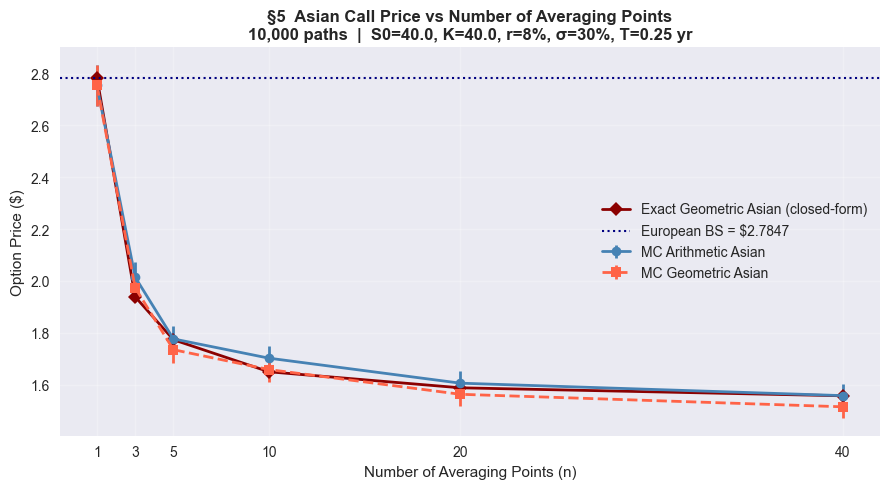

In [231]:
# ── §5 Asian Option — Effect of Number of Averaging Points ──────────
S0, K, r, q, sigma, T = 40.0, 40.0, 0.08, 0.00, 0.30, 0.25
from scipy.stats import norm as _norm

# ── Helper: exact discrete geometric Asian call (Kemna-Vorst, n discrete points) ─
# For n evenly-spaced averaging dates at h, 2h, ..., T:
#   sigma_g(n) = sigma * sqrt((n+1)(2n+1) / (6n^2))   → sigma/sqrt(3) as n→∞
#   b_g(n)     = (r-q-sigma^2/2)*(n+1)/(2n)            (mean of log G_n / S0 per unit T)
#              + sigma^2*(n+1)(2n+1)/(12n^2) - sigma_g^2/2
# Reduces to Black-Scholes at n=1, and to continuous Kemna-Vorst as n→∞
def exact_geom_asian(S0, K, T, r, q, sigma, n):
    sg = sigma * np.sqrt((n + 1) * (2 * n + 1) / (6 * n**2))   # annualised vol of log G_n
    # b_g: drift such that S0*exp(b_g*T) = E^Q[G_n]
    bg = ((r - q - 0.5 * sigma**2) * (n + 1) / (2 * n)
          + sigma**2 * (n + 1) * (2 * n + 1) / (12 * n**2))
    d1 = (np.log(S0 / K) + (bg + 0.5 * sg**2) * T) / (sg * np.sqrt(T))
    d2 = d1 - sg * np.sqrt(T)
    return np.exp(-r * T) * (S0 * np.exp(bg * T) * _norm.cdf(d1) - K * _norm.cdf(d2))

bs_ref = bs_call(S0, K, T, r, q, sigma)   # European reference (= exact_geom_asian at n=1)

# ── TABLE: 10,000 paths × varying number of averaging points ─────────
#   Columns: n | MC Arith | Arith SE | MC Geom | Geom SE | Exact Geom (closed-form)
#   n=1  → geometric exact = Black-Scholes (single terminal price)
#   n=∞  → geometric exact → continuous Kemna-Vorst ($1.5256)
n_avg_list    = [1, 3, 5, 10, 20, 40]
n_paths_asian = 10_000
rng_asian     = np.random.default_rng(42)

rows_avg = []
for n_avg in n_avg_list:
    h_avg = T / n_avg
    Z_avg   = rng_asian.standard_normal((n_paths_asian, n_avg))
    log_avg = (r - q - 0.5 * sigma**2) * h_avg + sigma * np.sqrt(h_avg) * Z_avg
    S_avg   = S0 * np.exp(np.cumsum(log_avg, axis=1))          # (N, n_avg)

    A_a = S_avg.mean(axis=1)                                   # arithmetic avg
    A_g = np.exp(np.log(S_avg).mean(axis=1))                   # geometric avg

    X_a = np.exp(-r * T) * np.maximum(A_a - K, 0.0)
    X_g = np.exp(-r * T) * np.maximum(A_g - K, 0.0)

    p_a   = X_a.mean();  se_pa = X_a.std(ddof=1) / np.sqrt(n_paths_asian)
    p_g   = X_g.mean();  se_pg = X_g.std(ddof=1) / np.sqrt(n_paths_asian)
    exact = exact_geom_asian(S0, K, T, r, q, sigma, n_avg)

    rows_avg.append((n_avg, p_a, se_pa, p_g, se_pg, exact))

# ── Print table ───────────────────────────────────────────────────────
W = 13
hdr = (f"{'n (avgs)':<10}"
       f"{'Arith Price':>{W}}{'Arith SE':>{W}}"
       f"{'Geom Price':>{W}}{'Geom SE':>{W}}"
       f"{'Exact Geom':>{W}}")
sep = "-" * len(hdr)

print(f"Table 19.2  Asian Call — {n_paths_asian:,} Paths, Varying Averaging Points")
print(f"  S0=${S0}, K=${K}, r={r*100:.0f}%, σ={sigma*100:.0f}%, T={T} yr")
print(sep); print(hdr); print(sep)
for (n_avg, p_a, se_pa, p_g, se_pg, exact) in rows_avg:
    print(f"{n_avg:<10}{p_a:>{W}.4f}{se_pa:>{W}.4f}"
          f"{p_g:>{W}.4f}{se_pg:>{W}.4f}{exact:>{W}.4f}")
print(sep)
print(f"{'Euro BS':<10}{bs_ref:>{W}.4f}{'---':>{W}}{'---':>{W}}{'---':>{W}}{'(n=1 exact)':>{W}}")
print(sep)
print(f"\n  n=1: Exact Geom = Black-Scholes (${bs_ref:.4f}) — a single price IS the geometric mean")
print(f"  As n ↑: exact geom falls → averaging reduces effective vol")
print(f"  MC Geom tracks Exact Geom closely (validation)")
print(f"  Arith Asian > Geom Asian at every n (Jensen's inequality)")

# ── CHART ─────────────────────────────────────────────────────────────
ns_plot   = [row[0] for row in rows_avg]
pa_plot   = [row[1] for row in rows_avg]
pg_plot   = [row[3] for row in rows_avg]
exact_plot= [row[5] for row in rows_avg]
sea_plot  = [row[2] for row in rows_avg]
seg_plot  = [row[4] for row in rows_avg]

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(ns_plot, pa_plot, yerr=[1.96*s for s in sea_plot],
            fmt='o-', color='steelblue', linewidth=2, capsize=5, label='MC Arithmetic Asian')
ax.errorbar(ns_plot, pg_plot, yerr=[1.96*s for s in seg_plot],
            fmt='s--', color='tomato', linewidth=2, capsize=5, label='MC Geometric Asian')
ax.plot(ns_plot, exact_plot, 'D-', color='darkred', linewidth=2, markersize=7,
        label='Exact Geometric Asian (closed-form)')
ax.axhline(bs_ref, color='navy', linestyle=':', linewidth=1.5,
           label=f'European BS = ${bs_ref:.4f}')
ax.set_xticks(ns_plot); ax.set_xticklabels([str(n) for n in ns_plot])
ax.set_xlabel('Number of Averaging Points (n)', fontsize=11)
ax.set_ylabel('Option Price ($)', fontsize=11)
ax.set_title(f'§5  Asian Call Price vs Number of Averaging Points\n'
             f'{n_paths_asian:,} paths  |  S0={S0}, K={K}, r={r*100:.0f}%, σ={sigma*100:.0f}%, T={T} yr',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()


## The Poisson Distribution

A **discrete probability distribution** that counts the number of events occurring over a time period.

- $\lambda h$ is the probability that one event occurs over the short interval $h$

- Over period $t$: probability of **exactly $m$ events** (PMF):

$$p(m,\,\lambda t) = \frac{e^{-\lambda t}\,(\lambda t)^m}{m!}$$

- **Cumulative** probability of $m$ or fewer events (CDF):

$$P(m,\,\lambda t) = \Pr(x \leq m;\,\lambda t) = \sum_{i=0}^{m} \frac{e^{-\lambda t}\,(\lambda t)^i}{i!}$$

- **Mean** $= \lambda t$, **Variance** $= \lambda t$

Given an **expected number of events $\lambda t$**, the Poisson distribution tells us the probability of seeing exactly $m$ events over the period — used to model the **number of jumps** in a stock price over a given horizon.


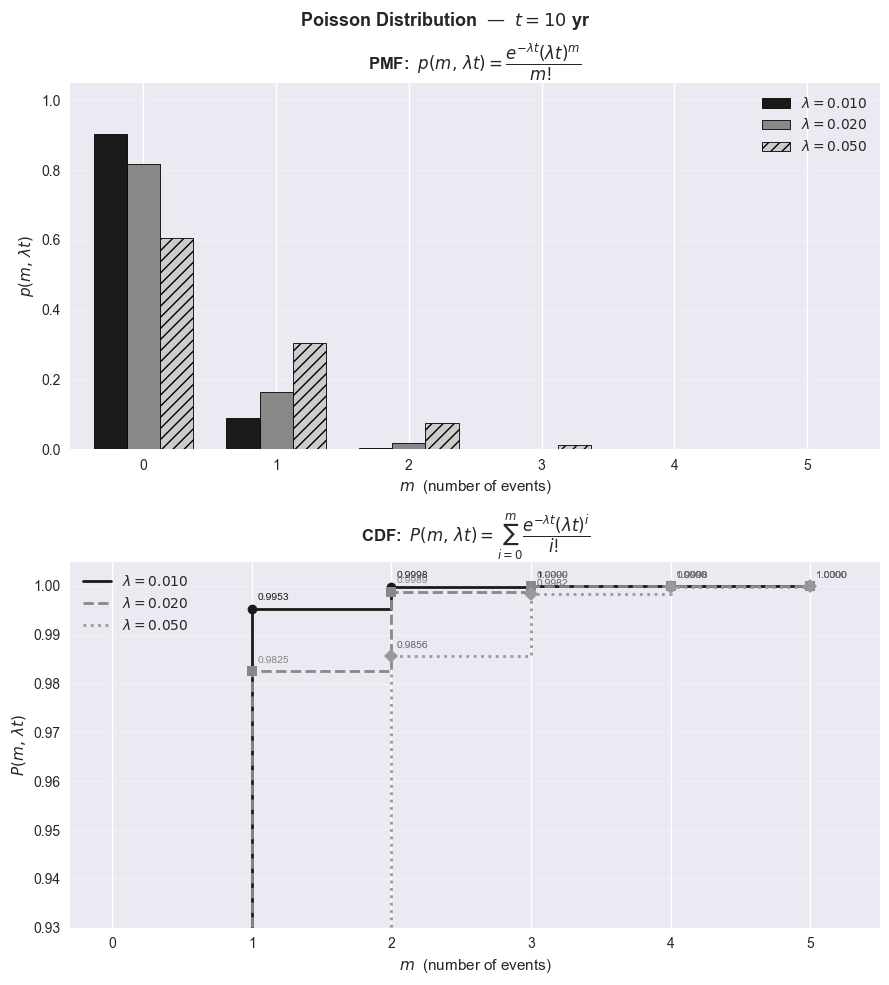

Poisson PMF  p(m, λt)  and  CDF  P(m, λt)  —  t = 10 yr

───────────────────────────────────────────────────────────────────
m    p(λ=0.01) p(λ=0.02) p(λ=0.05)  | P(λ=0.01) P(λ=0.02) P(λ=0.05)
───────────────────────────────────────────────────────────────────
0     0.904837  0.818731  0.606531  |  0.904837  0.818731  0.606531
1     0.090484  0.163746  0.303265  |  0.995321  0.982477  0.909796
2     0.004524  0.016375  0.075816  |  0.999845  0.998852  0.985612
3     0.000151  0.001092  0.012636  |  0.999996  0.999943  0.998248
4     0.000004  0.000055  0.001580  |  1.000000  0.999998  0.999828
5     0.000000  0.000002  0.000158  |  1.000000  1.000000  0.999986
───────────────────────────────────────────────────────────────────

  Mean = λt:  λ=0.01 → E[m]=0.100  |  λ=0.02 → E[m]=0.200  |  λ=0.05 → E[m]=0.500


In [256]:
# ── §8  Poisson PMF & CDF — replicating slide chart ─────────────────
# PMF:  p(m, λt) = e^{-λt} (λt)^m / m!
# CDF:  P(m, λt) = Σ_{i=0}^{m}  e^{-λt} (λt)^i / i!
from scipy.stats import poisson

t       = 10
lambdas = [0.010, 0.02, 0.050]
m_vals  = np.arange(0, 6)               # m = 0,1,2,3,4,5

pmfs = {lam: poisson.pmf(m_vals, lam * t) for lam in lambdas}
cdfs = {lam: poisson.cdf(m_vals, lam * t) for lam in lambdas}

bar_w   = 0.25
offsets = [-bar_w, 0, bar_w]
colors  = ['#1a1a1a', '#888888', '#cccccc']
hatches = ['', '', '///']
line_styles = ['-', '--', ':']
markers     = ['o', 's', 'D']

fig, (ax_pmf, ax_cdf) = plt.subplots(2, 1, figsize=(9, 10))

# ── Top: PMF bar chart ───────────────────────────────────────────────
for lam, off, col, hatch in zip(lambdas, offsets, colors, hatches):
    ax_pmf.bar(m_vals + off, pmfs[lam], width=bar_w,
               color=col, hatch=hatch, edgecolor='black', linewidth=0.6,
               label=f'$\\lambda = {lam:.3f}$')

ax_pmf.set_xlabel('$m$  (number of events)', fontsize=11)
ax_pmf.set_ylabel('$p(m,\\,\\lambda t)$', fontsize=11)
ax_pmf.set_title(r'PMF:  $p(m,\,\lambda t)=\dfrac{e^{-\lambda t}(\lambda t)^m}{m!}$',
                 fontsize=12, fontweight='bold')
ax_pmf.set_xticks(m_vals)
ax_pmf.set_xlim(-0.55, 5.55)
ax_pmf.set_ylim(0, 1.05)
ax_pmf.legend(fontsize=10, framealpha=0.9)
ax_pmf.grid(axis='y', alpha=0.25)

# ── Bottom: CDF step chart ───────────────────────────────────────────
for lam, col, ls, mk in zip(lambdas, colors, line_styles, markers):
    ax_cdf.step(m_vals, cdfs[lam], where='post',
                color=col if col != '#cccccc' else '#999999',
                linestyle=ls, linewidth=2,
                label=f'$\\lambda = {lam:.3f}$')
    ax_cdf.plot(m_vals, cdfs[lam], mk,
                color=col if col != '#cccccc' else '#999999',
                markersize=7)
    # annotate each CDF value
    for mv, cv in zip(m_vals, cdfs[lam]):
        ax_cdf.annotate(f'{cv:.4f}', xy=(mv, cv),
                        xytext=(4, 6), textcoords='offset points',
                        fontsize=7.5, color=col if col != '#cccccc' else '#666666')

ax_cdf.set_xlabel('$m$  (number of events)', fontsize=11)
ax_cdf.set_ylabel('$P(m,\\,\\lambda t)$', fontsize=11)
ax_cdf.set_title(r'CDF:  $P(m,\,\lambda t)=\sum_{i=0}^{m}\dfrac{e^{-\lambda t}(\lambda t)^i}{i!}$',
                 fontsize=12, fontweight='bold')
ax_cdf.set_xticks(m_vals)
ax_cdf.set_xlim(-0.3, 5.5)
ax_cdf.set_ylim(0.93, 1.005)
ax_cdf.legend(fontsize=10, framealpha=0.9)
ax_cdf.grid(axis='y', alpha=0.25)

plt.suptitle(f'Poisson Distribution  —  $t = {t}$ yr', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Combined table: PMF and CDF ───────────────────────────────────────
W = 10
print(f"Poisson PMF  p(m, λt)  and  CDF  P(m, λt)  —  t = {t} yr\n")
hdr = f"{'m':<4}" + "".join(f"{'p(λ='+str(l)+')':>{W}}" for l in lambdas) \
                  + "  |" + "".join(f"{'P(λ='+str(l)+')':>{W}}" for l in lambdas)
print("─"*len(hdr)); print(hdr); print("─"*len(hdr))
for mv in m_vals:
    row = f"{mv:<4}" \
        + "".join(f"{pmfs[l][mv]:>{W}.6f}" for l in lambdas) \
        + "  |" \
        + "".join(f"{cdfs[l][mv]:>{W}.6f}" for l in lambdas)
    print(row)
print("─"*len(hdr))
print(f"\n  Mean = λt:  " + "  |  ".join(f"λ={l} → E[m]={l*t:.3f}" for l in lambdas))


##  Simulating Jumps with the Poisson Distribution 

Stock prices can experience sudden large moves ("jumps") beyond what the lognormal model predicts. The **Merton jump-diffusion  gives:

$$\hat{S}_{t+h} = \hat{S}_t \; e^{(\alpha - \delta - \lambda k - 0.5\sigma^2)\,h \;+\; \sigma\sqrt{h}\,Z} \cdot e^{m(\alpha_J - 0.5\sigma_J^2)\;+\;\sigma_J \sum_{i=0}^{m} W_i}$$






── Eq. (19.16)  Parameter Summary ─────────────────────────────
   α=9.00%  δ=0.00%  σ=30.00%
   λ=3  αⱼ=-2.00%  σⱼ=5.00%
   k = e^(αⱼ + ½σⱼ²) − 1 = -0.018575
   λk (drift correction)  = -0.055726 per year



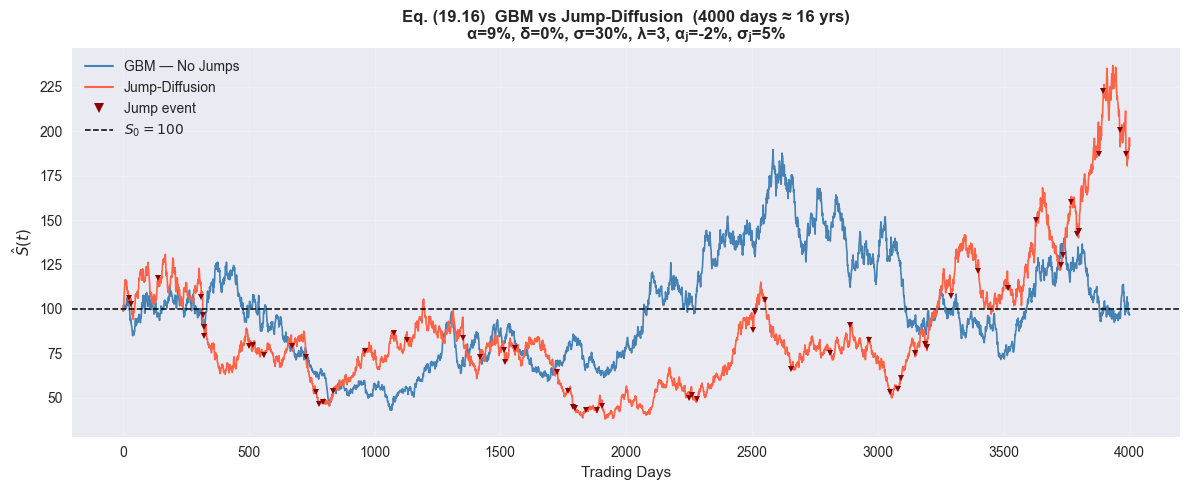

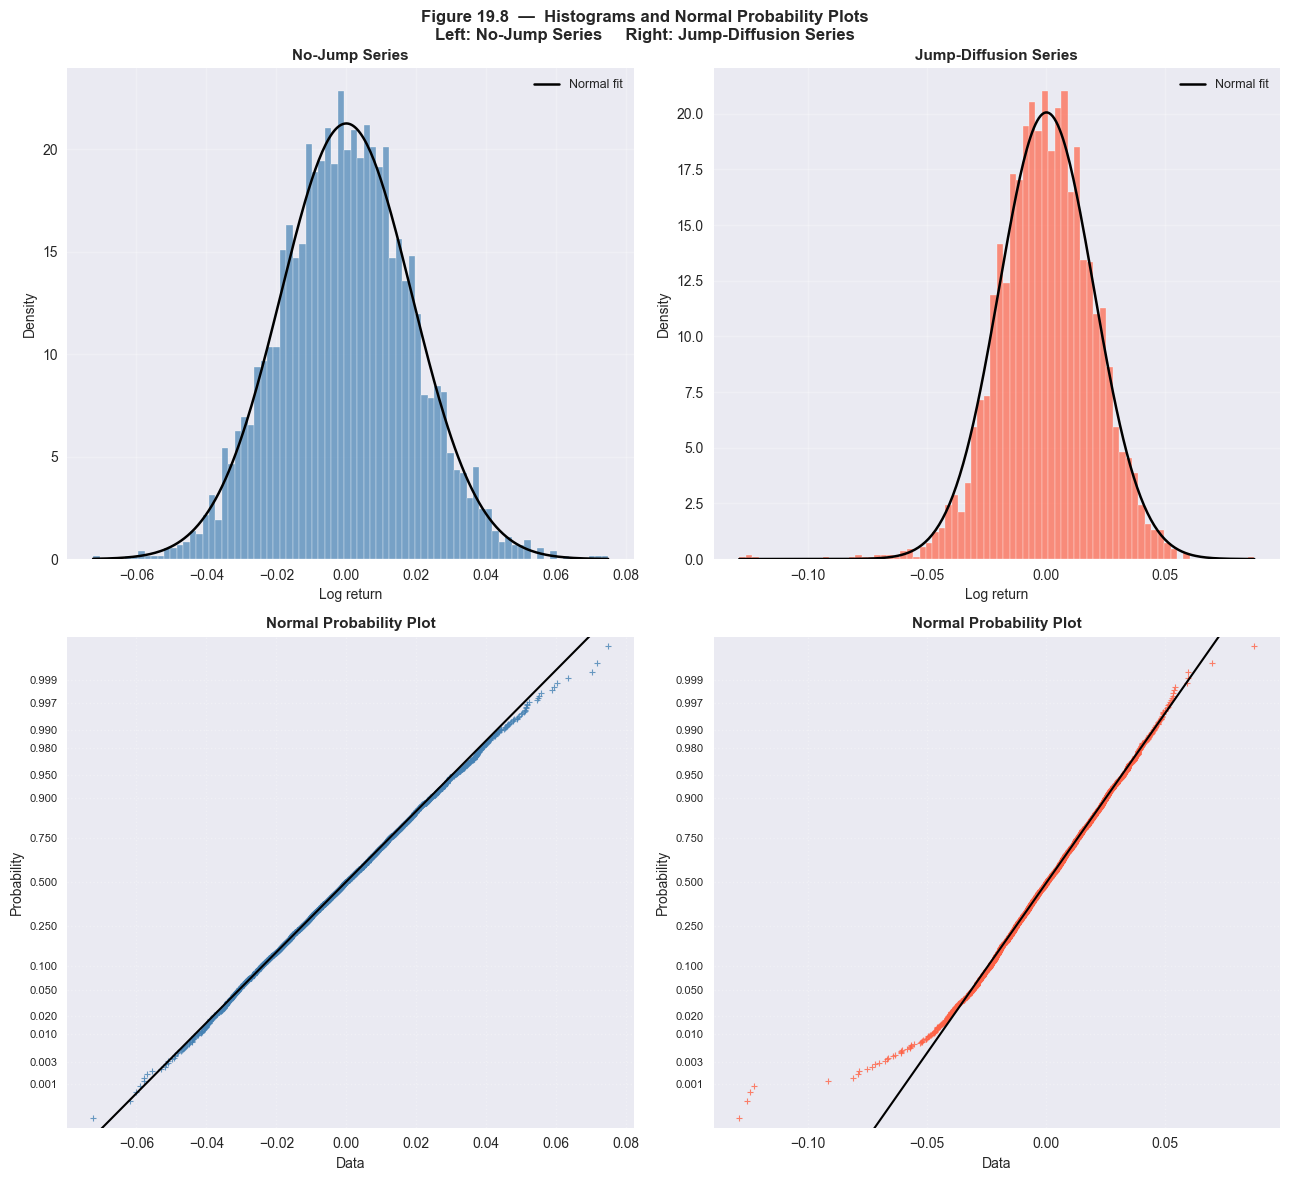

Return distribution statistics:

  No-jump (lognormal)        skew=+0.051  excess_kurt=+0.076  std=0.01877
  Jump-diffusion             skew=-0.348  excess_kurt=+1.792  std=0.01989

Jump-diffusion shows larger excess kurtosis → fatter tails than normal.


In [261]:
# ──  Jump-Diffusion Simulation — 
# α=9%, δ=0, σ=30%, λ=3, αⱼ=−2%, σⱼ=5%
from scipy.stats import probplot
from matplotlib.lines import Line2D

S0_lr      = 100.0
alpha_lr   =  0.09    # expected return  α
delta_lr   =  0.00    # dividend yield   δ
sigma_lr   =  0.30    # diffusion vol    σ
lam_lr     =  3       # jump intensity   λ  (expected jumps / yr)
alpha_J_lr = -0.02    # mean log-jump    αⱼ
sigma_J_lr =  0.05    # std  log-jump    σⱼ

# ── Drift correction: k = E[e^jump] − 1 ──────────────────────────────
k_lr = np.exp(alpha_J_lr + 0.5 * sigma_J_lr**2) - 1

n_days = 4_000
T_lr   = n_days / 252.0
h_day  = T_lr / n_days
t_days = np.arange(n_days + 1)

print("── Eq. (19.16)  Parameter Summary ─────────────────────────────")
print(f"   α={alpha_lr:.2%}  δ={delta_lr:.2%}  σ={sigma_lr:.2%}")
print(f"   λ={lam_lr}  αⱼ={alpha_J_lr:.2%}  σⱼ={sigma_J_lr:.2%}")
print(f"   k = e^(αⱼ + ½σⱼ²) − 1 = {k_lr:.6f}")
print(f"   λk (drift correction)  = {lam_lr*k_lr:.6f} per year\n")

rng_lr = np.random.default_rng(19)

# ── ONE GBM path — pure diffusion, no jumps ───────────────────────────
# S_{t+h} = S_t · exp[(α − δ − ½σ²)h + σ√h Z]
Z_gbm_lr    = rng_lr.standard_normal(n_days)
log_inc_gbm = (alpha_lr - delta_lr - 0.5 * sigma_lr**2) * h_day \
              + sigma_lr * np.sqrt(h_day) * Z_gbm_lr
S_gbm_lr    = np.concatenate([[S0_lr], S0_lr * np.exp(np.cumsum(log_inc_gbm))])

# ── ONE Jump-Diffusion path — with exact Poisson draws ───
# log-ret per step = (α − δ − λk − ½σ²)h + σ√h Z
#                  + m(αⱼ − ½σⱼ²) + σⱼ Σᵢ₌₁ᵐ Wᵢ
Z_jd_lr  = rng_lr.standard_normal(n_days)           # diffusion shocks
m_jd_lr  = rng_lr.poisson(lam_lr * h_day, n_days)   # Poisson jump counts per step

# vectorised jump-size sum: shape (n_days, max_m)
max_m_lr  = max(int(m_jd_lr.max()), 1)
W_jd_all  = rng_lr.standard_normal((n_days, max_m_lr))
mask_lr   = np.arange(max_m_lr)[None, :] < m_jd_lr[:, None]
sum_Wi_lr = (W_jd_all * mask_lr).sum(axis=1)         # Σ Wᵢ for each step

diff_ret_lr = (alpha_lr - delta_lr - lam_lr * k_lr - 0.5 * sigma_lr**2) * h_day \
              + sigma_lr * np.sqrt(h_day) * Z_jd_lr
jump_ret_lr = m_jd_lr * (alpha_J_lr - 0.5 * sigma_J_lr**2) \
              + sigma_J_lr * sum_Wi_lr

S_jd_lr  = np.concatenate([[S0_lr],
                S0_lr * np.exp(np.cumsum(diff_ret_lr + jump_ret_lr))])
ji_lr    = m_jd_lr > 0   # steps with ≥1 jump

# ── Combined price-path chart ─────────────────────────────────────────
fig, ax_comb = plt.subplots(figsize=(12, 5))
ax_comb.plot(t_days, S_gbm_lr, color='steelblue', linewidth=1.2)
ax_comb.plot(t_days, S_jd_lr,  color='tomato',    linewidth=1.2)
for jt in np.where(ji_lr)[0]:
    ax_comb.plot(jt + 1, S_jd_lr[jt + 1], 'v', color='darkred', markersize=4, zorder=5)
ax_comb.axhline(S0_lr, color='black', linestyle='--', linewidth=1.1,
                label=f'$S_0={S0_lr:.0f}$')
ax_comb.set_xlabel('Trading Days', fontsize=11)
ax_comb.set_ylabel('$\\hat{S}(t)$', fontsize=11)
ax_comb.set_title(
    f'Eq. (19.16)  GBM vs Jump-Diffusion  ({n_days} days \u2248 {T_lr:.0f} yrs)\n'
    f'\u03b1={alpha_lr:.0%}, \u03b4={delta_lr:.0%}, \u03c3={sigma_lr:.0%}, '
    f'\u03bb={lam_lr}, \u03b1\u2c7c={alpha_J_lr:.0%}, \u03c3\u2c7c={sigma_J_lr:.0%}',
    fontsize=12, fontweight='bold')
ax_comb.legend(handles=[
    Line2D([0],[0], color='steelblue', lw=1.5, label='GBM — No Jumps'),
    Line2D([0],[0], color='tomato',    lw=1.5, label='Jump-Diffusion'),
    Line2D([0],[0], marker='v', color='darkred', linestyle='None',
           markersize=7, label='Jump event'),
    Line2D([0],[0], color='black', linestyle='--', lw=1.1,
           label=f'$S_0={S0_lr:.0f}$'),
], fontsize=10, framealpha=0.9)
ax_comb.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# ── Return Distributions & Normal Probability Plots — Figure 19.8 ────
ret_nj = np.diff(np.log(S_gbm_lr))
ret_jd = np.diff(np.log(S_jd_lr))

fig2, axes2 = plt.subplots(2, 2, figsize=(13, 12))

# ── Top-left: histogram no-jump ───────────────────────────────────────
x_nj = np.linspace(ret_nj.min(), ret_nj.max(), 300)
axes2[0, 0].hist(ret_nj, bins=80, density=True, color='steelblue', alpha=0.70, edgecolor='white')
axes2[0, 0].plot(x_nj, norm.pdf(x_nj, ret_nj.mean(), ret_nj.std()), 'k-', lw=1.8, label='Normal fit')
axes2[0, 0].set_xlabel('Log return', fontsize=10)
axes2[0, 0].set_ylabel('Density', fontsize=10)
axes2[0, 0].set_title('No-Jump Series', fontsize=11, fontweight='bold')
axes2[0, 0].legend(fontsize=9)
axes2[0, 0].grid(alpha=0.25)

# ── Top-right: histogram with-jump ───────────────────────────────────
x_jd_lo = max(ret_jd.min(), -0.20)
x_jd_hi = min(ret_jd.max(), 0.20)
x_jd = np.linspace(x_jd_lo, x_jd_hi, 300)
axes2[0, 1].hist(ret_jd, bins=80, density=True, color='tomato', alpha=0.70, edgecolor='white')
axes2[0, 1].plot(x_jd, norm.pdf(x_jd, ret_jd.mean(), ret_jd.std()), 'k-', lw=1.8, label='Normal fit')
axes2[0, 1].set_xlabel('Log return', fontsize=10)
axes2[0, 1].set_ylabel('Density', fontsize=10)
axes2[0, 1].set_title('Jump-Diffusion Series', fontsize=11, fontweight='bold')
axes2[0, 1].legend(fontsize=9)
axes2[0, 1].grid(alpha=0.25)

# ── Probability scale for Normal Probability Plots ────────────────────
prob_ticks  = [0.001, 0.003, 0.010, 0.020, 0.050, 0.100, 0.250,
               0.500, 0.750, 0.900, 0.950, 0.980, 0.990, 0.997, 0.999]
prob_labels = ['0.001','0.003','0.010','0.020','0.050','0.100','0.250',
               '0.500','0.750','0.900','0.950','0.980','0.990','0.997','0.999']
probit_ticks = norm.ppf(prob_ticks)

# ── Bottom-left & Bottom-right: Normal Probability Plots ─────────────
for ax, ret, color, title in [
    (axes2[1, 0], ret_nj, 'steelblue', 'Normal Probability Plot'),
    (axes2[1, 1], ret_jd, 'tomato',    'Normal Probability Plot'),
]:
    n_r = len(ret)
    sorted_ret = np.sort(ret)
    # Blom plotting positions: P_i = (i - 0.375) / (n + 0.25)
    probs      = (np.arange(1, n_r + 1) - 0.375) / (n_r + 0.25)
    probit_y   = norm.ppf(probs)

    ax.plot(sorted_ret, probit_y, '+', color=color, markersize=5, markeredgewidth=0.8, alpha=0.8)

    # Reference line through the 25th and 75th percentiles
    q25, q75 = np.percentile(ret, [25, 75])
    p25, p75 = norm.ppf([0.25, 0.75])
    slope_pp  = (p75 - p25) / (q75 - q25)
    inter_pp  = p25 - slope_pp * q25
    x_ref_pp  = np.array([sorted_ret[0], sorted_ret[-1]])
    ax.plot(x_ref_pp, slope_pp * x_ref_pp + inter_pp, 'k-', lw=1.5)

    ax.set_yticks(probit_ticks)
    ax.set_yticklabels(prob_labels, fontsize=8)
    # Set y-limits to cover the full data range, not just the tick range
    y_margin = 0.15
    ax.set_ylim(min(probit_y.min(), probit_ticks[0])  - y_margin,
                max(probit_y.max(), probit_ticks[-1]) + y_margin)
    ax.set_ylabel('Probability', fontsize=10)
    ax.set_xlabel('Data', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.grid(alpha=0.3, linestyle=':')

plt.suptitle('Figure 19.8  —  Histograms and Normal Probability Plots\n'
             'Left: No-Jump Series     Right: Jump-Diffusion Series',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("Return distribution statistics:\n")
for lbl, ret in [('No-jump (lognormal)', ret_nj), ('Jump-diffusion', ret_jd)]:
    s = pd.Series(ret)
    print(f"  {lbl:25s}  skew={s.skew():+.3f}  excess_kurt={s.kurtosis():+.3f}  std={s.std():.5f}")
print("\nJump-diffusion shows larger excess kurtosis → fatter tails than normal.")
